## Poprawki
W odpowiedzi na uwagi z crossreview dokonałem następujących poraw:

* **Eliminacja wycieku danych w kroswalidacji:**
  * Wcześniej `StandardScaler` był dopasowywany jednorazowo na całym zbiorze treningowym przed wejściem do `GridSearchCV`.
  * Skalowanie zostało przeniesione do `Pipeline` z użyciem `ColumnTransformer`

* **Bezpieczne kodowanie cech (`OneHotEncoder` zamiast `get_dummies`):**
  * Zrezygnowałem z `pd.get_dummies`, które wywołane osobno na zbiorze treningowym i testowym mogło prowadzić do niezgodności liczby/kolejności kolumn.
  * Zastosowałem `OneHotEncoder(handle_unknown='ignore')`

* **Model bazowy (*Baseline*):**
  * Poprawiłem błąd logiczny, w którym `DummyClassifier` był trenowany na cechach po standaryzacji, a testowany na cechach nieskalowanych. Całość została ujednolicona w ramach potoku `Pipeline`.

* **Inżynieria cech z kolumn `Name` oraz `Ticket`:**
  * **`Title`:** Wyciągnąłem tytuły z nazwiska z grupowaniem rzadkich do kategorii `'Rare'`.
  * **`Ticket_count`:** Utworzyłem cechę zliczającą liczbę pasażerów na tym samym bilecie, co wychwytuje grupy podróżujące wspólnie.

* Inne poprawki:**
  * Zamiana `Pclass` na string i one-hot encodingu.
  * W tabelach przestawnych z  `aggfunc='max'` na `aggfunc='mean'`
  * Do `GridSearchCV` dodano parametr `return_train_score=True` oraz sporządzono wykres krzywych uczenia (*Train Score vs Validation Score*).

In [113]:
from google.colab import drive # remove the cell if not using colab
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [114]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix

from pathlib import Path
base_path = Path('/content/drive/MyDrive/WakacyjneWyzwanieML') # change path here!

# Klasyfikacja pasażerów Titanica
Nie wiemy czy dla DiCaprio było miejsce na drzwiach, ale wiemy że grdyby był tam Wojfer87 to by z nimi wyciskał pompki na górze lodowej. Teraz twoja pora na wyciskanie.
#Twoje zadnie to:
**stworzenie modelu przewidującego szanse przeżycia katastrofy Titanica**.

![https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPP![image.png](attachment:947faa8a-b43a-4f26-a1d2-f0cf947bc31e.png)SrXQ5rCbAgZ8EifWiiF.png](https://i1.jbzd.com.pl/contents/2025/11/normal/v5Fth4DcPpPPxSrXQ5rCbAgZ8EifWiiF.png "Wojfer")



#### Twoim celem będzie jest wytrenowanie modeli do klasyfikacji każdego pasażera Titanica jako ofiary (0) lub osoby, która przeżyła (1).

Poniżej znajdziesz pytania, które mogą być pomocne w zadaniu:

- Czego nauczyło Cię o badanym zbiorze danych poprzednie zadanie? Jak możesz wykorzystać wyciągnięte z niego wnioski w procesie tworzenia modelu?
- Jak przeprowadzenie standaryzacji danych może wpływać na zachowanie modelu?
- Co mój model robi i w jaki sposób?
- Jak nie przetrenować wybranego modelu?
- Jaki wynik klasyfikacji możemy uznać za *dobry*?


Wymagania:
- Wypisz obserwacje z pierwszego zadania, które pomogą Ci w tym. Co było przydatne, a co okazało się bezużyteczne?
- [Nie doprowadź](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html) do ~~przecieku statku~~ wycieku danych (np. nie ucz modelu na danych testowych). Nauczone modele odpal na danych treningowych i testowych - opisz uzyskane wyniki.
- Stwórz baseline, czyli dla porównania sprawdź jak z zadaniem radzi sobie [Dummy Classifier](https://scikit-learn.org/stable/modules/generated/sklearn.dummy.DummyClassifier.html) (jeśli Twój docelowy model radzi sobie gorzej - uciekaj)
- Przeprowadź badania na dwóch wybranych modelach uczenia maszynowego (np. spośród: drzew decyzyjnych, SVM, MLP, KNN, z gwiazdką [XGBoost](https://Xgboost.readthedocs.io/en/stable))
- W badaniach użyj wybranych metryk. Wybór uzasadnij.
- Dla każdego modelu wybierz co najmniej dwa hiperparametry i przeprowadź badania zależności wyników metryk od wartości hiperparametrów. Zwizualizuj wszystko ładnie, zastanów się dlaczego tak mogło być i wyciągnij i wypisz wnioski.
- Podsumuj przeprowadzone badania, wypisz wnioski.

Niezmiennie, zadbaj o czytelność kodu i nazewnictwo zmiennych. Jeśli jakiś wycinek kodu się powtarza, to wyodrębnij go do funkcji. Postaraj się zamieszczać swoje wnioski w postaci komentarza `Markdown`.

Jeśli chcesz, możesz sprawdzić (przyjmując pewne założenia), jakie byłyby Twoje szanse na Titanicu.

Uwaga! Jeśli Titanic to dla Ciebie nic i baaaaardzo chcesz to możesz w ramach tego zadania zająć się [bardziej wymagającym](https://archive.ics.uci.edu/dataset/365/polish+companies+bankruptcy+data) zbiorem.

# 1. Przygotownie i rozdzielenie danych




##Wnioski z pierwszego zadania:
Co było prydatne:
*   ``` SeX```,```Pclass``` i ```Fare``` miały największy wpływ na ```Survived```
* We wcześniejszym zadaniu za bardzo skupiłem się na ```Cabin``` i chiałem to podzielić na poszczególne sektory. Mogło to być za dużo dlatego zmienię to na flagę ```HasCabin```.
* Trzeba wyskalować ```Fare``` ze względ na outliery.
* Połączę ze soba FamilySize i IsAlone w jedną kolumnę. Jak wcześniej zauważyłem największe szanse na przeżycie miały małe rodziny 2-4,dlatego podzielę FamilyCategory: alone, small family, large family.

Co do usunięcia:
* ```PassagerID``` i ```Ticket``` losowy indetyfikator i losowy bilet, bezwawrtościowe dane co do uczenia
* ```Name``` nic nie dający ciąg znaków





In [115]:
titanic_df = pd.read_csv(base_path / 'titanic.csv', index_col='PassengerId')

In [116]:
titanic_df['Cabin'].str[0].unique()

array([nan, 'C', 'E', 'G', 'D', 'A', 'B', 'F', 'T'], dtype=object)

In [117]:
titanic_df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
PassengerId,,,,,,,,,,,
1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [118]:
# Wyskalowanie fare
titanic_df['Fare'] = np.log1p(titanic_df['Fare'])
# Zamiana na flage HasCabin
titanic_df['HasCabin'] = titanic_df['Cabin'].notna().astype(int)
# Dodanie FamilyCategory
family_size = titanic_df['SibSp'] + titanic_df['Parch'] + 1
titanic_df['FamilyCategory'] = pd.cut(family_size, bins=[0, 1, 4, np.inf], labels=['Alone', 'Small', 'Large'])
# Zamiana Pclass na stringa, żeby była kategorią

#titanic_df['Pclass'] = titanic_df['Pclass'].astype(str)  wg zalecenia


# Dodaje opcje zliczenia biletów
ticket_count = titanic_df['Ticket'].map(titanic_df['Ticket'].value_counts())
titanic_df['Ticket_count'] = ticket_count


In [119]:
titanic_df['Ticket_count'].value_counts(dropna=False)

,count
Ticket_count,
1,547
2,188
3,63
4,44
7,21
6,18
5,10


In [120]:
titanic_df['Title'] = titanic_df['Name'].str.split(', ', expand=True)[1].str.split('.', expand=True)[0].str.strip()
# ujednolicenie synonimów francuskich / skrótów
titanic_df['Title'] = titanic_df['Title'].replace({
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs'
})

rare_titles = ['Dr', 'Rev', 'Col', 'Major', 'the Countess', 'Lady', 'Sir', 'Don', 'Jonkheer', 'Capt']
titanic_df['Title'] = titanic_df['Title'].replace(rare_titles, 'Rare')

print(titanic_df['Title'].value_counts())

Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64


In [121]:
titanic_df = titanic_df.drop(columns=['Name', 'Ticket', 'Parch', 'SibSp', 'Cabin'])

Teraz dzielę dane na zbiór testowy i treningowy.

In [122]:
X = titanic_df.drop(columns=['Survived'])
y = titanic_df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=67, stratify=y, shuffle=True)

embarked_mode = X_train['Embarked'].mode()[0]
X_train['Embarked'] = X_train['Embarked'].fillna(embarked_mode)
X_test['Embarked'] = X_test['Embarked'].fillna(embarked_mode)

fare_medians = X_train.groupby('Pclass')['Fare'].median()
X_train['Fare'] = X_train['Fare'].fillna(X_train['Pclass'].map(fare_medians))
X_test['Fare'] = X_test['Fare'].fillna(X_test['Pclass'].map(fare_medians))

# Uzupełnienie medianą ze względu na Pclass i Sex z X_train

age_medians = X_train.groupby(['Pclass', 'Sex'])['Age'].median()

X_train['Age'] = X_train['Age'].fillna(X_train.groupby(['Pclass', 'Sex'])['Age'].transform('median'))

test_fill_values = pd.Series(X_test.set_index(['Pclass', 'Sex']).index.map(age_medians), index=X_test.index)
X_test['Age'] = X_test['Age'].fillna(test_fill_values)


Kodowanie danych, poprawione

In [123]:
num_features = ['Age', 'Fare', 'Pclass', 'Ticket_count']
cat_features = ['Sex', 'Embarked', 'FamilyCategory', 'Title', 'HasCabin']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])

# dla knn
scaled_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
    ])


# 2. Dobór metryk


*   Accuracy -  procent wszystkich pooprawnych wskazań
*   Precision - jak duży odsetek pasażerów zaklasyfikowanych jako ocaleni faktycznie przeżył (false positive)
*   Recall - pokazuje, jaką część ze wszystkich faktycznie ocalałych pasażerów model zdołał wykryć (false negative)
*   F1-Score - średnia harmoniczna precision i recall
*   Confusion Matrix - umożliwa podgląd rozkładu błędów


# 3. Baseline DummyClassifier

In [135]:
#poprawione
dummy_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DummyClassifier(strategy='most_frequent', random_state=67))
])

dummy_pipeline.fit(X_train, y_train)

y_pred_dummy = dummy_pipeline.predict(X_test)

print("Dummy classifier")
print(classification_report(y_test, y_pred_dummy, zero_division=0))
print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_dummy))

Dummy classifier
              precision    recall  f1-score   support

           0       0.61      1.00      0.76       110
           1       0.00      0.00      0.00        69

    accuracy                           0.61       179
   macro avg       0.31      0.50      0.38       179
weighted avg       0.38      0.61      0.47       179

Macierz pomyłek:
[[110   0]
 [ 69   0]]


Model bazowy typujący osiąga dokładność na poziomie ~61%.

# 4. Drzewa decyzyjne

In [125]:
siatka_drzewo = {
    'classifier__max_depth': list(range(1, 10)),
    'classifier__criterion': ['gini', 'entropy'],
    'classifier__min_samples_leaf': [2, 4, 6, 8, 10],
    'classifier__min_samples_split': [2, 4, 6, 8, 10]
}

dt_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=67))
])

szukaj_drzewo = GridSearchCV(
    estimator=dt_pipeline,
    param_grid=siatka_drzewo,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

szukaj_drzewo.fit(X_train, y_train)

print("Najlepsze hiperparametry:", szukaj_drzewo.best_params_)
print(f"Średni wynik w kroswalidacji: {szukaj_drzewo.best_score_:.4f}")

Najlepsze hiperparametry: {'classifier__criterion': 'gini', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 2}
Średni wynik w kroswalidacji: 0.8315


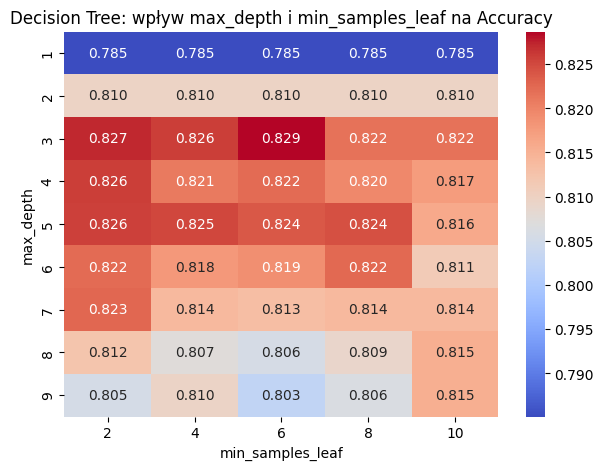

In [126]:
wyniki_drzewo = pd.DataFrame(szukaj_drzewo.cv_results_)

pivot_drzewo_test = wyniki_drzewo.pivot_table(
    values='mean_test_score',
    index='param_classifier__max_depth',
    columns='param_classifier__min_samples_leaf',
    aggfunc='mean' # poprawioen z max
)
pivot_drzewo_train = wyniki_drzewo.pivot_table(
    values='mean_train_score',
    index='param_classifier__max_depth',
    columns='param_classifier__min_samples_leaf',
    aggfunc='mean' # poprawioen z max
)


plt.figure(figsize=(7, 5))
sns.heatmap(pivot_drzewo_test, annot=True, fmt='.3f', cmap='coolwarm')
plt.title('Decision Tree: wpływ max_depth i min_samples_leaf na Accuracy')
plt.xlabel('min_samples_leaf')
plt.ylabel('max_depth')
plt.show()

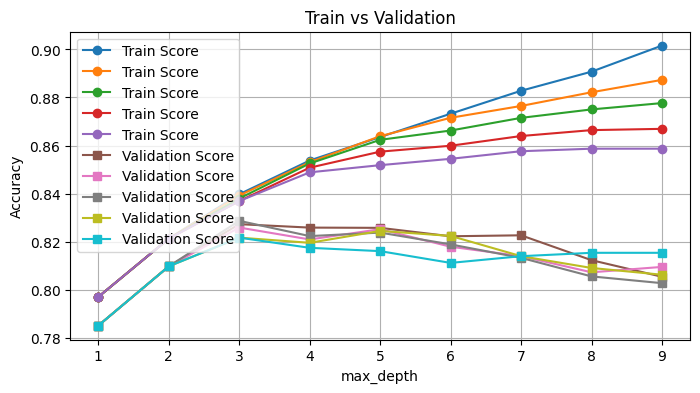

In [127]:
plt.figure(figsize=(8, 4))
plt.plot(pivot_drzewo_train, label='Train Score', marker='o')
plt.plot(pivot_drzewo_test, label='Validation Score', marker='s')
plt.title('Train vs Validation')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()



*   Niedouczenie dla małych głębokości: Dla max_depth = 1 (0.785) oraz max_depth = 2 (0.810) model jest zbyt prosty, przez co nie jest w stanie uchwycić nieliniowych zależności między cechami.
*   Optimum przy max_depth = 3
*  Przeuczenie (Overfitting) przy max_depth >= 4


In [128]:
tabela = pd.DataFrame(szukaj_drzewo.cv_results_)
tabela = tabela[['param_classifier__max_depth', 'param_classifier__criterion', 'param_classifier__min_samples_leaf',
                 'mean_test_score', 'std_test_score']]
tabela.sort_values('mean_test_score', ascending=False).head(10)

,param_classifier__max_depth,param_classifier__criterion,param_classifier__min_samples_leaf,mean_test_score,std_test_score
53,3,gini,2,0.831508,0.017302
50,3,gini,2,0.831508,0.017302
52,3,gini,2,0.831508,0.017302
54,3,gini,2,0.831508,0.017302
51,3,gini,2,0.831508,0.017302
62,3,gini,6,0.831488,0.013694
61,3,gini,6,0.831488,0.013694
63,3,gini,6,0.831488,0.013694
60,3,gini,6,0.831488,0.013694
64,3,gini,6,0.831488,0.013694


In [129]:
najlepsze_drzewo = szukaj_drzewo.best_estimator_

# Zbiór treningowy
y_pred_train_dt = najlepsze_drzewo.predict(X_train)
print("Zbiór treningowy")
print(classification_report(y_train, y_pred_train_dt))

# Zbiór testowy
y_pred_test_dt = najlepsze_drzewo.predict(X_test)
print("Zbiór testowy")
print(classification_report(y_test, y_pred_test_dt))

print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_test_dt))

Zbiór treningowy
              precision    recall  f1-score   support

           0       0.85      0.91      0.88       439
           1       0.83      0.75      0.79       273

    accuracy                           0.85       712
   macro avg       0.84      0.83      0.83       712
weighted avg       0.84      0.85      0.84       712

Zbiór testowy
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       110
           1       0.73      0.64      0.68        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.77      0.77      0.77       179

Macierz pomyłek:
[[94 16]
 [25 44]]


Wyniki przed wporwadzeniem zmian:

* Zbiór treningowy: Accuracy: 0.84, Precision (1): 0.83, Recall (1): 0.74, F1 (1): 0.78.

* Zbiór testowy: Accuracy: 0.78, Precision (1): 0.74, Recall (1): 0.65, F1 (1): 0.69.

Wyniki po zmianach:

* Zbiór treningowy: Accuracy: 0.85, Precision (1): 0.83, Recall (1): 0.75, F1 (1): 0.79.

* Zbiór testowy: Accuracy: 0.77, Precision (1): 0.73, Recall (1): 0.64, F1 (1): 0.68.



Wyniki po zmianach minimalnie zmalały.

# 5. KNN

In [130]:
from sklearn.neighbors import KNeighborsClassifier

siatka_knn = {
    'classifier__n_neighbors': list(range(1, 21)),
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan', 'cosine']
}

kn_pipeline = Pipeline([
    ('preprocessor', scaled_preprocessor),
    ('classifier', KNeighborsClassifier())
])

szukaj_knn = GridSearchCV(
    estimator=kn_pipeline,
    param_grid=siatka_knn,
    cv=5,
    scoring='accuracy',
    return_train_score=True,
    n_jobs=-1
)

szukaj_knn.fit(X_train, y_train)

print("Najlepsze hiperparametry:", szukaj_knn.best_params_)
print(f"Średni wynik w kroswalidacji: {szukaj_knn.best_score_:.4f}")

Najlepsze hiperparametry: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 9, 'classifier__weights': 'uniform'}
Średni wynik w kroswalidacji: 0.8414


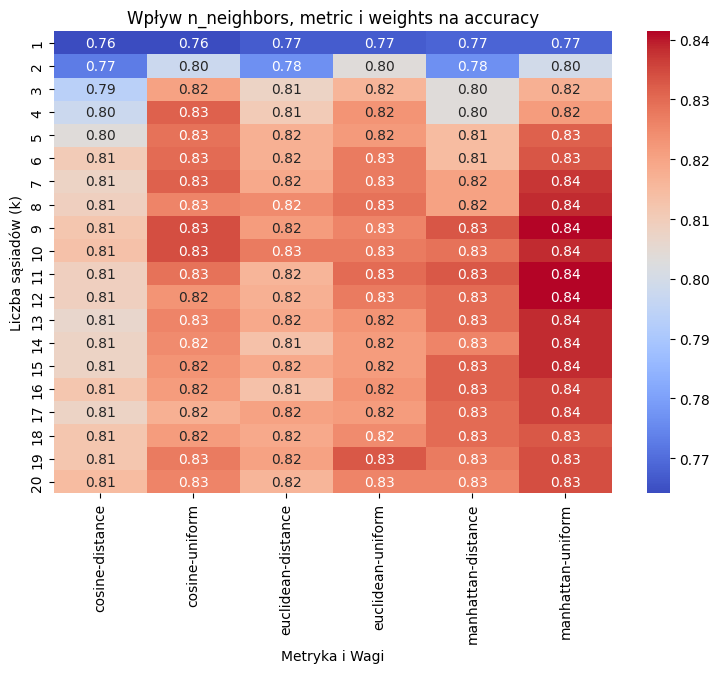

In [131]:
wyniki_knn = pd.DataFrame(szukaj_knn.cv_results_)

pivot_knn = wyniki_knn.pivot_table(
    values='mean_test_score',
    index='param_classifier__n_neighbors',
    columns=['param_classifier__metric', 'param_classifier__weights'],
    aggfunc='mean' # poprawione z max
)

plt.figure(figsize=(9, 6))
sns.heatmap(pivot_knn, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Wpływ n_neighbors, metric i weights na accuracy')
plt.xlabel('Metryka i Wagi')
plt.ylabel('Liczba sąsiadów (k)')
plt.show()



*   Przeuczenie dla małych $k$: Dla $k = 1$ oraz $k = 2$ dokładność w walidacji wynosi jedynie 0.76–0.77.
*   Wpływ wag: Uniform okazały się stabilniejsze i skuteczniejsze niż ważenie odległością.
*  Optymalne pasmo sąsiedztwa ($k \in [8, 12]$). Dla $k > 15$ widoczny jest powolny spadek do poziomu ~0.80–0.81.


In [132]:
tabela = pd.DataFrame(szukaj_knn.cv_results_)
tabela = tabela[['param_classifier__n_neighbors', 'mean_test_score', 'param_classifier__metric',
                 'param_classifier__weights']]
tabela.sort_values('mean_test_score', ascending=False).head(30)

,param_classifier__n_neighbors,mean_test_score,param_classifier__metric,param_classifier__weights
56,9,0.841387,manhattan,uniform
60,11,0.841367,manhattan,uniform
62,12,0.841357,manhattan,uniform
54,8,0.838599,manhattan,uniform
58,10,0.838580,manhattan,uniform
68,15,0.838550,manhattan,uniform
66,14,0.838550,manhattan,uniform
64,13,0.838540,manhattan,uniform
52,7,0.837171,manhattan,uniform
70,16,0.835743,manhattan,uniform


* Metryka cosine oraz manhattan osiągnęły lepsze rezultaty (0.8259 i 0.8217) niż standardowa metryka euklidesowa (0.8216). (przed zmainiami)
* Metryka manhattan(0.8413), cosine(0.8343) i euklidesowa(0.8329). (po zmianach wyniki minimalnie wzrosły)

In [133]:
najlepszy_knn = szukaj_knn.best_estimator_

# Zbiór treningowy
y_pred_train_knn = najlepszy_knn.predict(X_train)
print("Zbiór Treningowy")
print(classification_report(y_train, y_pred_train_knn))

# Zbiór testowy
y_pred_test_knn = najlepszy_knn.predict(X_test)
print("Zbiór Testowy")
print(classification_report(y_test, y_pred_test_knn))

print("Macierz pomyłek:")
print(confusion_matrix(y_test, y_pred_test_knn))

Zbiór Treningowy
              precision    recall  f1-score   support

           0       0.85      0.92      0.88       439
           1       0.85      0.74      0.79       273

    accuracy                           0.85       712
   macro avg       0.85      0.83      0.84       712
weighted avg       0.85      0.85      0.85       712

Zbiór Testowy
              precision    recall  f1-score   support

           0       0.80      0.87      0.83       110
           1       0.76      0.65      0.70        69

    accuracy                           0.79       179
   macro avg       0.78      0.76      0.77       179
weighted avg       0.79      0.79      0.78       179

Macierz pomyłek:
[[96 14]
 [24 45]]


Przed wprowadzonymi zmianami:

* Zbiór treningowy: Accuracy: 0.85, Precision (1): 0.87, Recall (1): 0.66, F1 (1): 0.75.

* Zbiór testowy: Accuracy: 0.76, Precision (1): 0.75, Recall (1): 0.57, F1 (1): 0.64.

Po zmianach:

* Zbiór treningowy: Accuracy: 0.85, Precision (1): 0.85, Recall (1): 0.74, F1 (1): 0.79.

* Zbiór testowy: Accuracy: 0.79, Precision (1): 0.76, Recall (1): 0.65, F1 (1): 0.70.


# 6. Wnioski

### Przed zmianiami
Oba modele znacząco pobiły minimalny próg wyznaczony przez Dummy Classifier (około 61.5%).

Drzewo decyzyjne okazało się modelem lepszym do tego zadania. Uzyskało wyższą dokładność na teście (78% vs 76%), lepszą stabilność w kroswalidacji (84.1% vs 82.6%) oraz wyraźnie wyższy Recall dla ocalałych (65% vs 57%), co oznacza, że skuteczniej identyfikuje pasażerów, którzy przeżyli katastrofę.
### Po zmimanach

KNN po zmianach okazał się minimalnie lepszy od drzew decyzyjnych. Wyższa dokładność na teście (77% vs 79%), lepszą stabilność w kroswalidacji (83% vs 84%) oraz porównywalny Recall dla ocalałych (65% vs 65%),

Drzewa decyczyjne spadły po zmianach o około 1 p.p. na każdej metryce, natomiast KNN gwałtowanie wzrósł. Miało na to wpływ:
*  Zmiana `Pclass` z one-hot encodingu na rzecz cechy numerycznej
*  Dodanie dodatkowych cech jak `Title` i `Ticket_count`



